DSAI LAB 1

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('Crop Production.csv')

In [4]:
df.isnull()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
246086,False,False,False,False,False,False,False
246087,False,False,False,False,False,False,False
246088,False,False,False,False,False,False,False
246089,False,False,False,False,False,False,False


In [5]:
df.isnull().sum()

State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

The above output has all entries in the dataframe as false and the sum is also 0 indicating that no cell in the dataframe has a null value.

In [6]:
print(df.duplicated().sum())

0


Here we check which rows are duplicate; if any row is duplicate, the function returns true and the sum function adds the number of true instances to present the total number of duplicate entries. Sum=0 suggests that there are no duplicate entries.

In [7]:
df['Season'] = df['Season'].astype(str)
print(df.dtypes)

State_Name        object
District_Name     object
Crop_Year          int64
Season            object
Crop              object
Area             float64
Production       float64
dtype: object


object in pandas means string datatype

In [8]:
df['Season'] = df['Season'].str.strip()

removed whitespaces from each cell of the season column

In [9]:
df['Season'] = df['Season'].str.replace('Kharif', 'Summer')
df['Season'] = df['Season'].str.replace('Rabi', 'Winter')

In [10]:
df['Crop_Year'] = df['Crop_Year'].astype(str)
print(df.dtypes)

State_Name        object
District_Name     object
Crop_Year         object
Season            object
Crop              object
Area             float64
Production       float64
dtype: object


astype converted the datatype and dtypes checks the data type of each column of the dataframe

TASK 1:

In [11]:
selected_columns = ['Area', 'Production']
correlation_matrix = df[selected_columns].corr()
print(correlation_matrix)

                Area  Production
Area        1.000000    0.040587
Production  0.040587    1.000000


only selected the numeric datatype columns to form the correlation

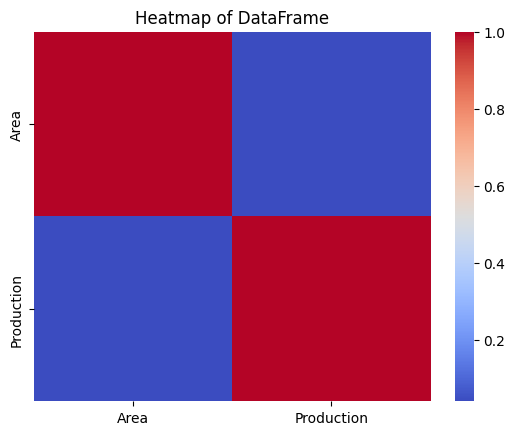

In [12]:
sns.heatmap(correlation_matrix, cmap='coolwarm')
plt.title('Heatmap of DataFrame')
plt.show()

TASK 2:

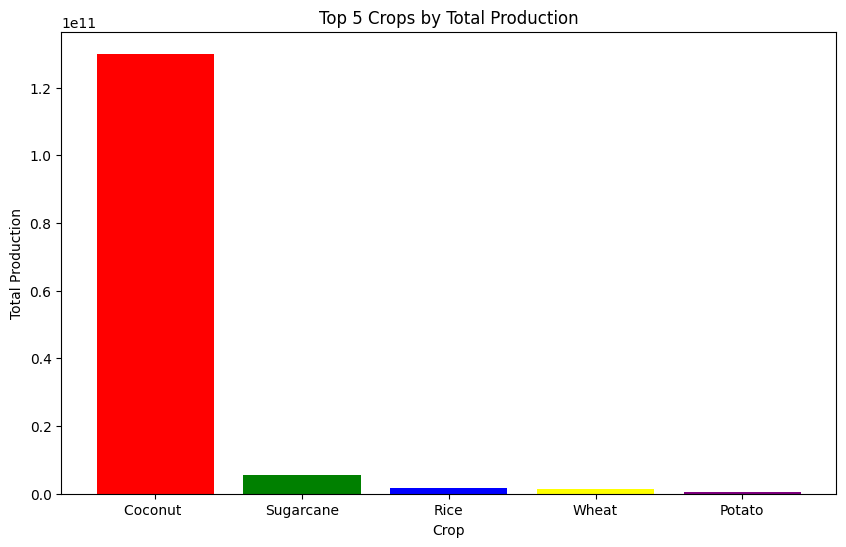

In [13]:
crop_totals = df.groupby('Crop')['Production'].sum().sort_values(ascending=False)
top_5 = crop_totals.head(5)
colors = ['red', 'green', 'blue', 'yellow', 'purple']
plt.figure(figsize=(10, 6))
bars = plt.bar(top_5.index, top_5.values, color=colors)
plt.xlabel('Crop')
plt.ylabel('Total Production')
plt.title('Top 5 Crops by Total Production')
plt.show()

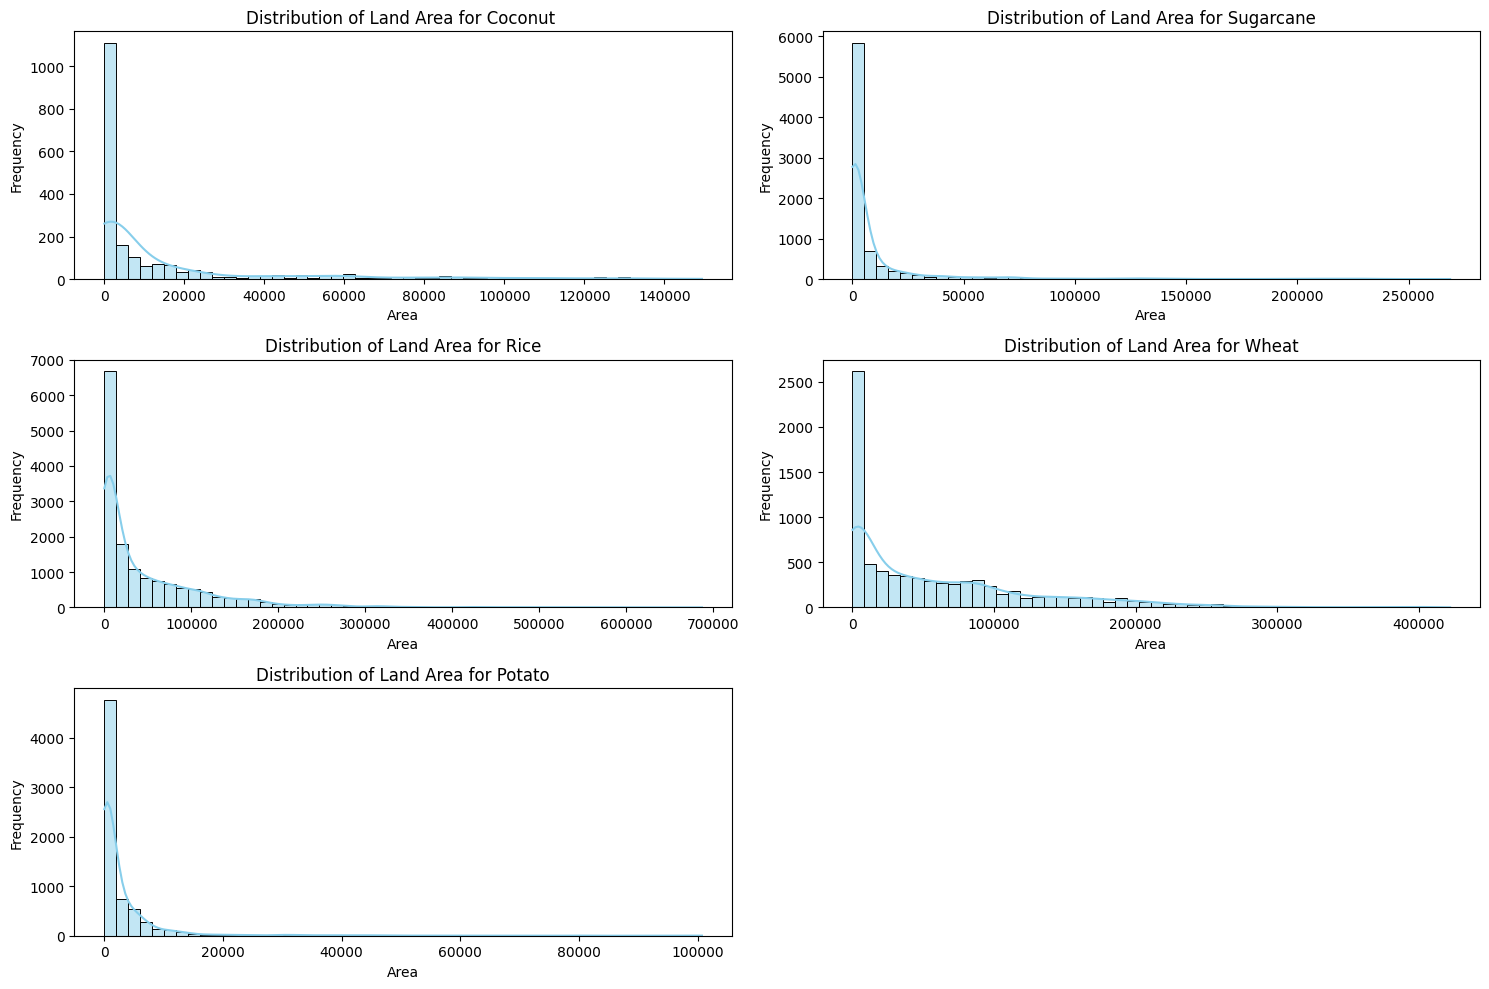

In [19]:
top_5_crops = df.groupby('Crop')['Production'].sum().sort_values(ascending=False).head(5).index

plt.figure(figsize=(15, 10))

for i, crop in enumerate(top_5_crops, 1):
    plt.subplot(3, 2, i)  # 3 rows, 2 columns layout
    sns.histplot(data=df[df['Crop'] == crop], x='Area', bins=50, kde=True, color='skyblue')
    plt.title(f'Distribution of Land Area for {crop}')
    plt.xlabel('Area')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

in this code snippet, first i find the top 5 crops and store their names in top_5_crops. then using a for loop i draw a histogram for every crop using bin value of 50. KDE: Kernel Density Estimation, estimates the pdf of a continuous variable.

data = df[df['Crop'] == crop]

this line filters the dataframe df to include only those rows where the crop column matches a specific column name.

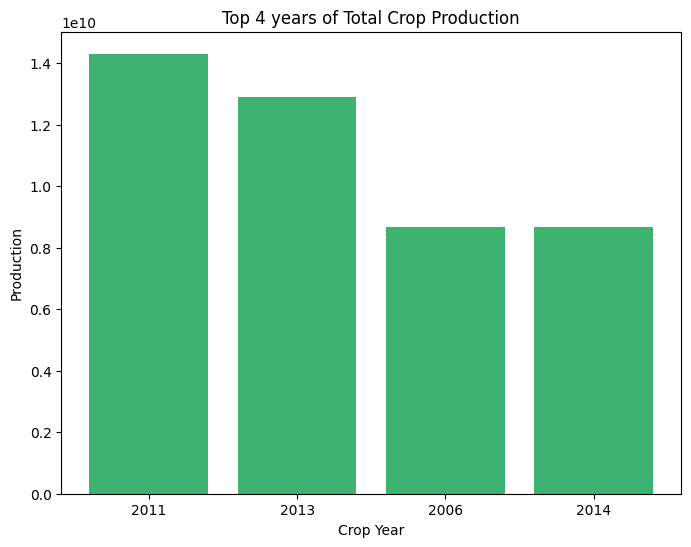

In [21]:
yearly_production = df.groupby('Crop_Year')['Production'].sum()
top_4_years = yearly_production.sort_values(ascending = False).head(4)
plt.figure(figsize=(8,6))
plt.bar(top_4_years.index.astype(str), top_4_years.values, color='mediumseagreen')
plt.xlabel('Crop Year')
plt.ylabel('Production')
plt.title('Top 4 years of Total Crop Production')
plt.show()

here i first grouped the crops by year and and summed their production for that year. after that i stored the top 4 values of production along with their years in top_4_years. this was followed by simple plotting of the bar graph

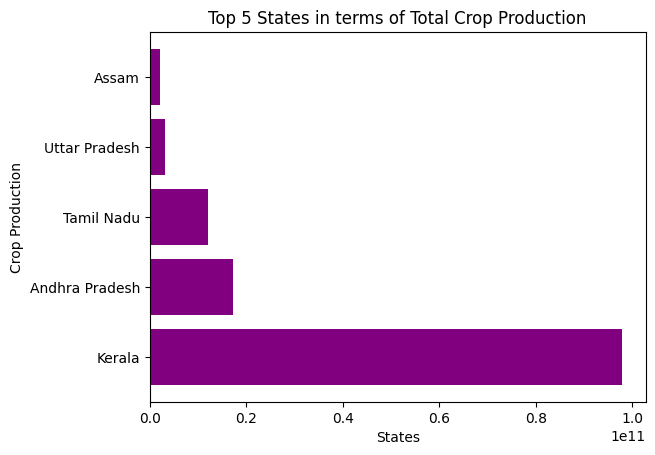

In [26]:
statewise_production = df.groupby('State_Name')['Production'].sum()
top_5_states = statewise_production.sort_values(ascending=False).head(5)
plt.Figure(figsize=(8,6))
plt.barh(top_5_states.index.astype(str), top_5_states.values, color='purple')
plt.title("Top 5 States in terms of Total Crop Production")
plt.xlabel('States')
plt.ylabel("Crop Production")
plt.show()

stored total crop production and name of top 5 states in top_5_states and then created the bargraph accordingly

TASK 3:

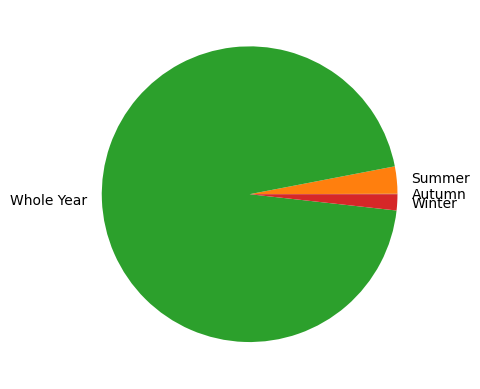

In [30]:
seasonal_production = df.groupby('Season')['Production'].sum()
plt.pie(seasonal_production.values, labels = seasonal_production.index)
plt.show()

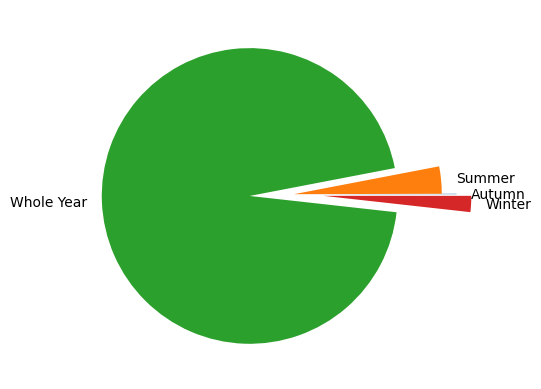

In [29]:
seasonal_production = df.groupby('Season')['Production'].sum()
exp = [0.1, 0.0, 0.3, 0.2]
plt.pie(seasonal_production.values, labels = seasonal_production.index, explode = exp)
plt.show()

here i created 2 separate pie charts to show the difference of how whole year crops dominate and summer winter and autumn have a relatively less share in the total crop production

TASK 4:

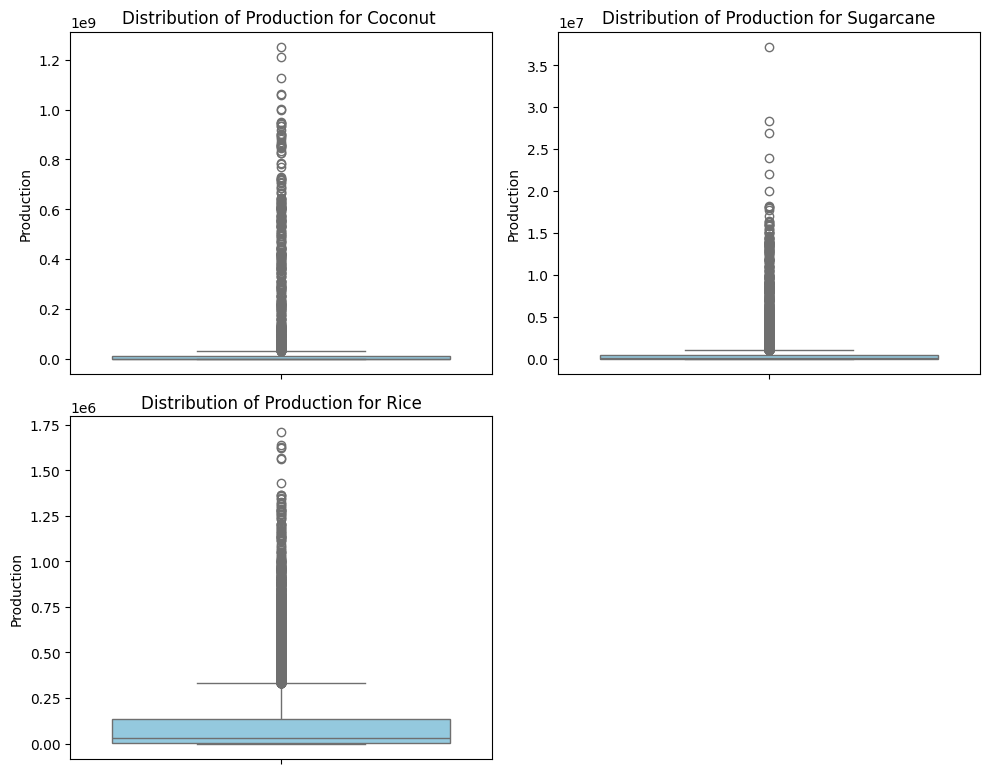

In [ ]:
top_3_crops = df.groupby('Crop')['Production'].sum().sort_values(ascending=False).head(3).index

plt.figure(figsize=(10,8))

for i, crop in enumerate(top_3_crops, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df[df['Crop'] == crop], y='Production', color='skyblue')
    plt.title(f'Distribution of Production for {crop}')
    plt.ylabel('Production')

plt.tight_layout()
plt.show()